In [2]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
uploaded = files.upload()

Mounted at /content/drive


Saving student_depression_dataset.csv to student_depression_dataset.csv


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("student_depression_dataset.csv")

y = df["Depression"]

X_A = df.drop(columns=["id", "Depression"])

X_B = df.drop(columns=["id", "Depression", "Have you ever had suicidal thoughts ?"])

X_train_A, X_test_A, y_train, y_test = train_test_split(
    X_A, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_B = X_train_A.drop(columns=["Have you ever had suicidal thoughts ?"])
X_test_B = X_test_A.drop(columns=["Have you ever had suicidal thoughts ?"])



In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def entrenar_logistic(X_train, X_test, y_train, y_test):
    num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object"]).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000))
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    return model, y_pred

print("LOGISTIC A")
model_logA, y_pred_logA = entrenar_logistic(X_train_A, X_test_A, y_train, y_test)

print("LOGISTIC B")
model_logB, y_pred_logB = entrenar_logistic(X_train_B, X_test_B, y_train, y_test)

LOGISTIC A
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581

LOGISTIC B
              precision    recall  f1-score   support

           0       0.77      0.72      0.75      2313
           1       0.81      0.85      0.83      3268

    accuracy                           0.80      5581
   macro avg       0.79      0.79      0.79      5581
weighted avg       0.80      0.80      0.80      5581



In [5]:
from sklearn.ensemble import RandomForestClassifier

def entrenar_rf(X_train, X_test, y_train, y_test):
    num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object"]).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ))
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    return model, y_pred

print("RF A")
model_rfA, y_pred_rfA = entrenar_rf(X_train_A, X_test_A, y_train, y_test)

print("RF B")
model_rfB, y_pred_rfB = entrenar_rf(X_train_B, X_test_B, y_train, y_test)

RF A
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581

RF B
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      2313
           1       0.81      0.85      0.83      3268

    accuracy                           0.79      5581
   macro avg       0.79      0.78      0.78      5581
weighted avg       0.79      0.79      0.79      5581



In [6]:
!pip -q install xgboost
from xgboost import XGBClassifier

def entrenar_xgb(X_train, X_test, y_train, y_test):
    num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
    cat_cols = X_train.select_dtypes(include=["object"]).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=400,
                max_depth=5,
                learning_rate=0.05,
                random_state=42,
                eval_metric="logloss"
            ))
        ]
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    return model, y_pred

print("XGB A")
model_xgbA, y_pred_xgbA = entrenar_xgb(X_train_A, X_test_A, y_train, y_test)

print("XGB B")
model_xgbB, y_pred_xgbB = entrenar_xgb(X_train_B, X_test_B, y_train, y_test)

XGB A
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581

XGB B
              precision    recall  f1-score   support

           0       0.77      0.73      0.75      2313
           1       0.81      0.85      0.83      3268

    accuracy                           0.80      5581
   macro avg       0.79      0.79      0.79      5581
weighted avg       0.80      0.80      0.80      5581



In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def resumen(nombre, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

rows = [
    resumen("Logistic A", y_pred_logA),
    resumen("Logistic B", y_pred_logB),
    resumen("RF A", y_pred_rfA),
    resumen("RF B", y_pred_rfB),
    resumen("XGBoost A", y_pred_xgbA),
    resumen("XGBoost B", y_pred_xgbB),
]

df_metrics = pd.DataFrame(rows).sort_values(by="F1", ascending=False)

df_metrics

,Modelo,Accuracy,Precision,Recall,F1
0,Logistic A,0.842860,0.857613,0.877295,0.867342
4,XGBoost A,0.841426,0.855566,0.877295,0.866294
2,RF A,0.838380,0.847124,0.883415,0.864889
5,XGBoost B,0.798244,0.814261,0.849143,0.831336
1,Logistic B,0.796452,0.812793,0.847613,0.829838
3,RF B,0.792331,0.805387,0.850979,0.827555


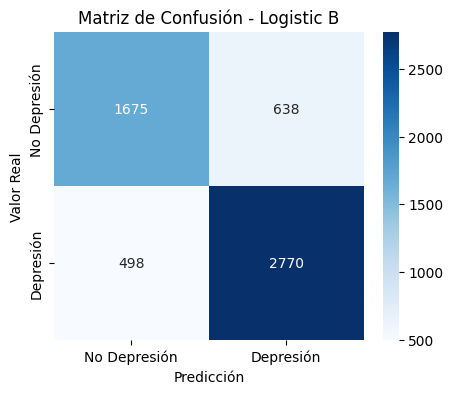

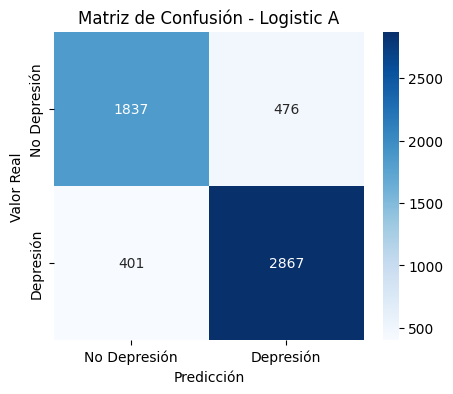

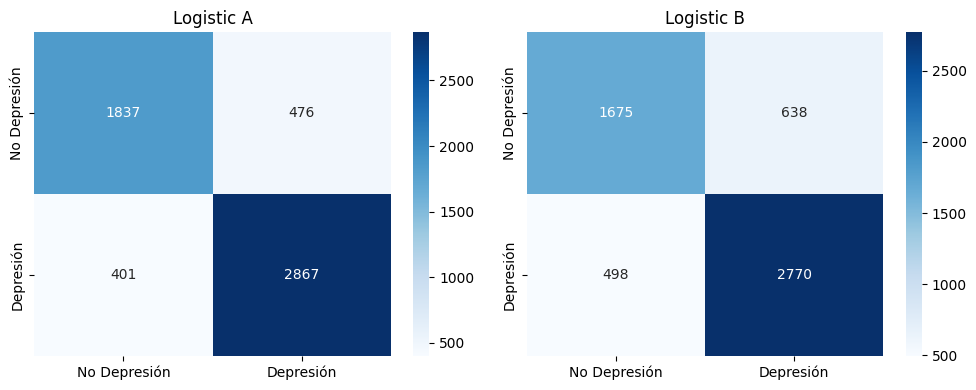

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_logB = confusion_matrix(y_test, y_pred_logB)

plt.figure(figsize=(5,4))
sns.heatmap(cm_logB, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión", "Depresión"],
            yticklabels=["No Depresión", "Depresión"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Logistic B")
plt.show()

cm_logB

cm_logA = confusion_matrix(y_test, y_pred_logA)

plt.figure(figsize=(5,4))
sns.heatmap(cm_logA, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión", "Depresión"],
            yticklabels=["No Depresión", "Depresión"])

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - Logistic A")
plt.show()

cm_logA

fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_logA, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión", "Depresión"],
            yticklabels=["No Depresión", "Depresión"],
            ax=axes[0])
axes[0].set_title("Logistic A")

sns.heatmap(cm_logB, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depresión", "Depresión"],
            yticklabels=["No Depresión", "Depresión"],
            ax=axes[1])
axes[1].set_title("Logistic B")

plt.tight_layout()
plt.show()



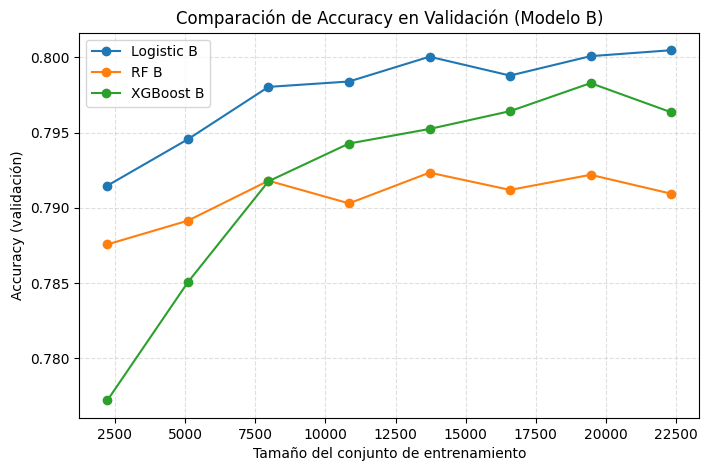

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold

def plot_learning_curve(models_dict, X, y, title="Comparación de accuracy en validación"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes = np.linspace(0.1, 1.0, 8)

    plt.figure(figsize=(8,5))

    for name, model in models_dict.items():
        sizes, train_scores, val_scores = learning_curve(
            model, X, y,
            cv=cv,
            scoring="accuracy",
            train_sizes=train_sizes,
            n_jobs=-1
        )
        val_mean = val_scores.mean(axis=1)
        plt.plot(sizes, val_mean, marker="o", label=name)

    plt.title(title)
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("Accuracy (validación)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

models_dict = {
    "Logistic B": model_logB,
    "RF B": model_rfB,
    "XGBoost B": model_xgbB
}

plot_learning_curve(models_dict, X_B, y, title="Comparación de Accuracy en Validación (Modelo B)")

In [10]:
from sklearn.model_selection import GridSearchCV

In [11]:
num_cols_B = X_train_B.select_dtypes(include=["int64", "float64"]).columns
cat_cols_B = X_train_B.select_dtypes(include=["object"]).columns

preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_B),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_B)
    ]
)

pipe_log = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("classifier", LogisticRegression())
    ]
)

param_grid_log = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs"],
    "classifier__max_iter": [1000]
}

grid_log = GridSearchCV(
    pipe_log,
    param_grid_log,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(X_train_B, y_train)

print("Mejores hiperparámetros Logistic:")
print(grid_log.best_params_)

print("\nMejor F1 en validación cruzada:")
print(grid_log.best_score_)

Mejores hiperparámetros Logistic:
{'classifier__C': 0.01, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Mejor F1 en validación cruzada:
0.833098784556323


In [12]:
pipe_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

param_grid_rf = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train_B, y_train)

print("Mejores hiperparámetros Random Forest:")
print(grid_rf.best_params_)

print("\nMejor F1 validación cruzada:")
print(grid_rf.best_score_)

Mejores hiperparámetros Random Forest:
{'classifier__max_depth': 15, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Mejor F1 validación cruzada:
0.8332528763335405


In [13]:
pipe_xgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("classifier", XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

param_grid_xgb = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.01, 0.1, 0.2],
    "classifier__subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train_B, y_train)

print("Mejores hiperparámetros XGBoost:")
print(grid_xgb.best_params_)

print("\nMejor F1 validación cruzada:")
print(grid_xgb.best_score_)

Mejores hiperparámetros XGBoost:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}

Mejor F1 validación cruzada:
0.8340204016133523


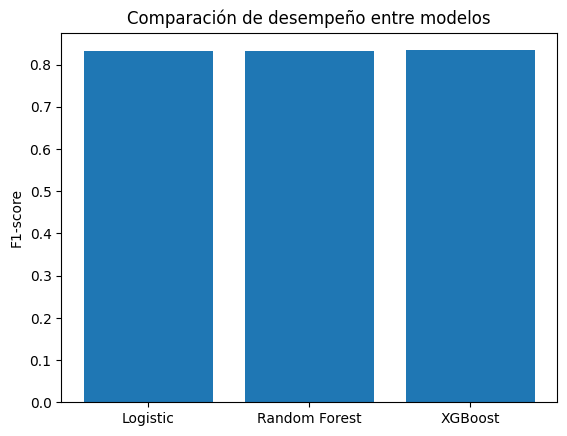

In [14]:
results = pd.DataFrame({
    "Modelo": ["Logistic", "Random Forest", "XGBoost"],
    "F1": [0.8331, 0.8333, 0.8340]
})

plt.figure()
plt.bar(results["Modelo"], results["F1"])
plt.ylabel("F1-score")
plt.title("Comparación de desempeño entre modelos")
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_log_model = grid_log.best_estimator_
best_rf_model = grid_rf.best_estimator_
best_xgb_model = grid_xgb.best_estimator_

y_pred_final = best_log_model.predict(X_test_B)

print(classification_report(y_test, y_pred_final))




              precision    recall  f1-score   support

           0       0.77      0.72      0.75      2313
           1       0.81      0.85      0.83      3268

    accuracy                           0.80      5581
   macro avg       0.79      0.79      0.79      5581
weighted avg       0.80      0.80      0.80      5581



Text(0.5, 1.0, 'Matriz de confusión normalizada – Regresión logística optimizada')

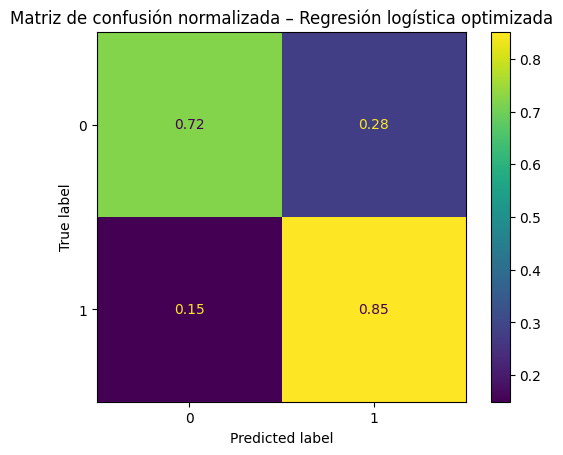

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    normalize="true",
    cmap="viridis"
)

plt.title("Matriz de confusión normalizada – Regresión logística optimizada")

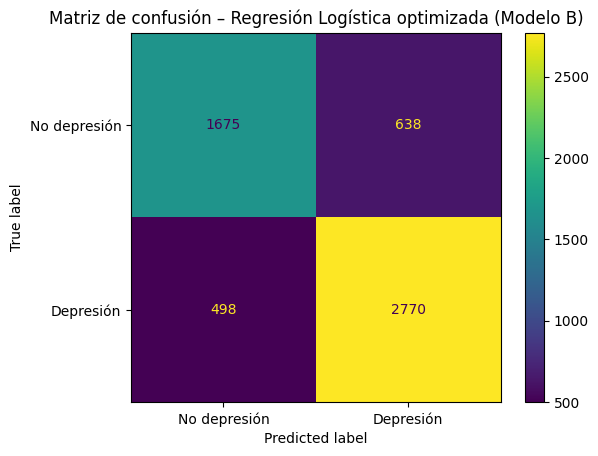

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logB,
    display_labels=["No depresión", "Depresión"]
)

disp.plot()
plt.title("Matriz de confusión – Regresión Logística optimizada (Modelo B)")
plt.show()

In [18]:


data = {
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Hiperparámetros explorados": [
        "C",
        "n_estimators, max_depth, min_samples_split, min_samples_leaf",
        "learning_rate, max_depth, n_estimators, subsample"
    ],

    "Mejores hiperparámetros": [
        "C = 0.01",
        "n_estimators = 300, max_depth = 15",
        "learning_rate = 0.1, max_depth = 3"
    ],

    "F1 validación": [
        0.833,
        0.833,
        0.834
    ]
}

df = pd.DataFrame(data)

df.style.hide(axis="index")

Modelo,Hiperparámetros explorados,Mejores hiperparámetros,F1 validación
Logistic Regression,C,C = 0.01,0.833000
Random Forest,"n_estimators, max_depth, min_samples_split, min_samples_leaf","n_estimators = 300, max_depth = 15",0.833000
XGBoost,"learning_rate, max_depth, n_estimators, subsample","learning_rate = 0.1, max_depth = 3",0.834000


In [19]:

data = {
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [0.80, 0.81, 0.85, 0.83]
}

df_metrics = pd.DataFrame(data)


styled_table = (
    df_metrics.style
    .format({"Valor": "{:.2f}"})
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "font-size": "14px"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [("font-weight", "bold"),
                   ("text-align", "center"),
                   ("font-size", "14px")]},
        {"selector": "table",
         "props": [("border-collapse", "collapse"),
                   ("margin", "0 auto")]},
        {"selector": "td, th",
         "props": [("border", "1px solid black"),
                   ("padding", "6px")]}
    ])
)

styled_table

Métrica,Valor
Accuracy,0.80
Precision,0.81
Recall,0.85
F1-score,0.83


In [20]:
import joblib

best_log_model = grid_log.best_estimator_
joblib.dump(best_log_model, "modelo_depresion_logistico.pkl")

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [21]:
import joblib

columnas_modelo = X_train_B.columns.tolist()
joblib.dump(columnas_modelo, "columnas_modelo.pkl")

print("Columnas guardadas correctamente")
print(columnas_modelo)

Columnas guardadas correctamente
['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']


In [24]:
%%writefile api_modelo.py
import joblib
import pandas as pd
from fastapi import FastAPI

modelo = joblib.load("modelo_depresion_logistico.pkl")
columnas = joblib.load("columnas_modelo.pkl")

app = FastAPI()

@app.get("/")
def home():
    return {"mensaje": "API de predicción de depresión activa"}

@app.post("/predict")
def predecir(datos: dict):
    df = pd.DataFrame([datos])
    df = df[columnas]
    pred = modelo.predict(df)[0]
    return {"prediccion": int(pred)}

Writing api_modelo.py


In [25]:
!pip install fastapi uvicorn nest-asyncio pyngrok

In [26]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn

nest_asyncio.apply()

In [28]:
import threading
import uvicorn

def correr_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=correr_api)
thread.start()

In [29]:
import requests

respuesta = requests.get("http://127.0.0.1:8000/")
print(respuesta.status_code)
print(respuesta.json())

INFO:     127.0.0.1:40192 - "GET / HTTP/1.1" 200 OK
200
{'mensaje': 'API de predicción de depresión activa'}


In [32]:
ejemplo_real = X_test_B.iloc[0].to_dict()
print(ejemplo_real)

{'Gender': 'Female', 'Age': 20.0, 'City': 'Ludhiana', 'Profession': 'Student', 'Academic Pressure': 2.0, 'Work Pressure': 0.0, 'CGPA': 6.37, 'Study Satisfaction': 3.0, 'Job Satisfaction': 0.0, 'Sleep Duration': "'7-8 hours'", 'Dietary Habits': 'Unhealthy', 'Degree': "'Class 12'", 'Work/Study Hours': 11.0, 'Financial Stress': '5.0', 'Family History of Mental Illness': 'Yes'}


In [33]:
respuesta = requests.post("http://127.0.0.1:8000/predict", json=ejemplo_real)
print(respuesta.status_code)
print(respuesta.text)

INFO:     127.0.0.1:43560 - "POST /predict HTTP/1.1" 200 OK
200
{"prediccion":1}


In [35]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 822.0/822.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.1 MB/s eta 0:00:00


In [38]:
import mlflow

mlflow.set_tracking_uri("http://3.91.192.29:8050")
mlflow.set_experiment("Proyecto_Depresion")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1773098477360, experiment_id='2', last_update_time=1773098477360, lifecycle_stage='active', name='Proyecto_Depresion', tags={}, workspace='default'>

In [39]:
with mlflow.start_run():

    mlflow.log_param("modelo", "Logistic Regression")
    mlflow.log_metric("accuracy", 0.80)
    mlflow.log_metric("f1_score", 0.83)

🏃 View run melodic-vole-480 at: http://3.91.192.29:8050/#/experiments/2/runs/e18b9a62a70e4501b249883e2b7fcfcf
🧪 View experiment at: http://3.91.192.29:8050/#/experiments/2


In [31]:
import requests

ejemplo = {
    "Gender": "Male",
    "Age": 21,
    "City": "Delhi",
    "Profession": "Student",
    "Academic Pressure": 3.0,
    "Work Pressure": 0.0,
    "CGPA": 7.5,
    "Study Satisfaction": 3.0,
    "Job Satisfaction": 0.0,
    "Sleep Duration": "5-6 hours",
    "Dietary Habits": "Moderate",
    "Degree": "B.Pharm",
    "Have you ever had suicidal thoughts ?": "No",
    "Work/Study Hours": 8.0,
    "Financial Stress": 3.0,
    "Family History of Mental Illness": "No"
}

respuesta = requests.post("http://127.0.0.1:8000/predict", json=ejemplo)
print(respuesta.status_code)
print(respuesta.json())

INFO:     127.0.0.1:54026 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

500


JSONDecodeError: Expecting value: line 1 column 1 (char 0)